In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

df = pd.read_csv('../data/cleaned_data.csv')
X, y = df.drop('target', axis=1), df['target']
    
#  Split Data: 80% Train, 20% Test 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
    
    #  Hyperparameter Tuning using GridSearchCV
print(" Tuning hyperparameters ")
param_grid = {
        'max_depth': [3, 4, 5,7],                
        'min_samples_split': [10, 20, 30],  
        'min_samples_leaf': [10, 15, 20],
        'class_weight': ['balanced']
    }
    
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
    
best_model = grid_search.best_estimator_
print(f"  Hyperparameters found: {grid_search.best_params_}")
    
y_pred = best_model.predict(X_test)
    
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"\n Model Performance on Test Set:")
    
print(classification_report(y_test, y_pred))


 Tuning hyperparameters 
  Hyperparameters found: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 20, 'min_samples_split': 10}

 Model Performance on Test Set:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        24
           1       0.84      0.84      0.84        37

    accuracy                           0.80        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.80      0.80      0.80        61



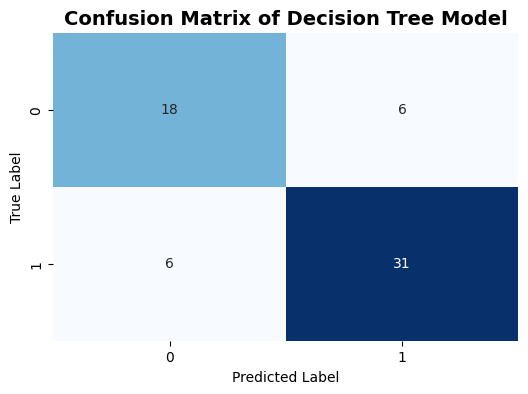

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix of Decision Tree Model', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()